# Task 1
*IN THIS TASK WE FIND THE PATIENT HAVE HEART DISEASE OR NOT *

# Intro

The Heart Disease dataset contains medical attributes of patients such as age, cholesterol, blood pressure, and heart rate. The objective of this dataset is to predict whether a patient has heart disease or not. It is widely used in machine learning for classification tasks and helps in early detection of cardiovascular problems.

In [1]:
#IMPORT THE LIBRIERS OR TOLLS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import cross_val_score

we import panads and numpy for data preprocessing but mostly pandas use for data preprocesssing

And matplotlib for data visualization to under stand data  quickle and for that the non-tech person also understand the data 

In [2]:
#LOAD THE DATA SET
dt=pd.read_csv("/kaggle/input/datasets/naveedarslan/heartdisese/heartdieases uci.csv")
df=pd.DataFrame(dt)
print(df.head())
#print(df)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  



* use "read_csv" because we have the data in csv file .The "read_cvs" help to open the file
* we also use "DataFrame" keyword we use this because this will help to apply the pandas functions on data set.This keyword help to apply the function e.g the "shape" & ".isnull()sum()" functions and etc
* For quick overview that over data set is  propley load we ise "head" function this will show the first 5 rows fo data set

In [3]:
#OVER VIEW OF DATA
sh=df.shape  # check rows and columns 
print(sh)
shp=df.describe()
print(shp)
inf=df.info() # check the data type 
print(inf)

(1025, 14)
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    

* in data set we have 14 columns and 1025 rows

In [4]:
# check the non value
val=df.isnull().sum() 
print(val)
#not found any nan-value

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


**visualize data**

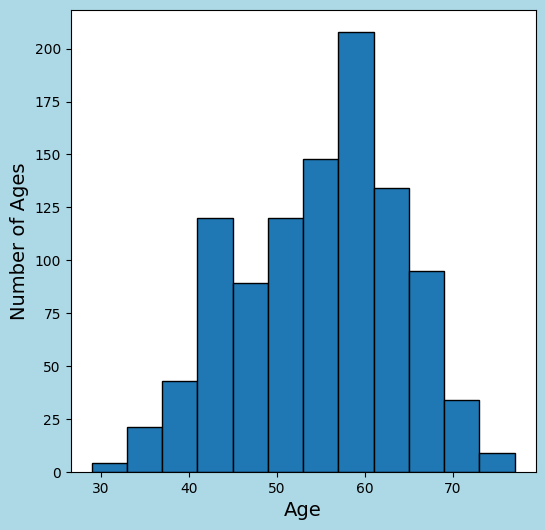

In [26]:
#age columns 
plt.figure(facecolor='LightBlue',figsize=(6,6))
plt.hist(df["age"],bins=12,edgecolor='black')
plt.xlabel("Age",fontsize=14)
plt.ylabel("Number of Ages",fontsize=14)
plt.show()

> In histogram chat we visualize how many patient with same age
* In the dataset, 200 patients are aged between 58 to 61,this is the most higest same age peoples

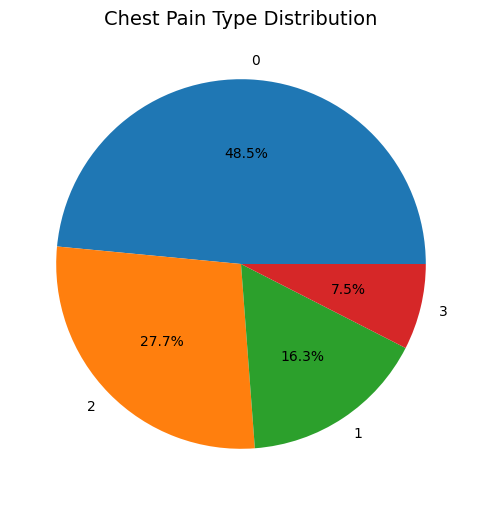

0=Typical Angina 1=Atypical Angina 2=Non-Anginal Pain 3=Asymptomatic


In [9]:
#chest pain distribution
plt.figure(figsize=(6,6))
cp=df['cp'].value_counts()
plt.pie(cp.values,labels=cp.index,autopct="%1.1f%%")
plt.title("Chest Pain Type Distribution",fontsize=14)
plt.show()
print(
"0=""Typical Angina",
"1=""Atypical Angina",
"2=" "Non-Anginal Pain",
"3=" "Asymptomatic"      
)

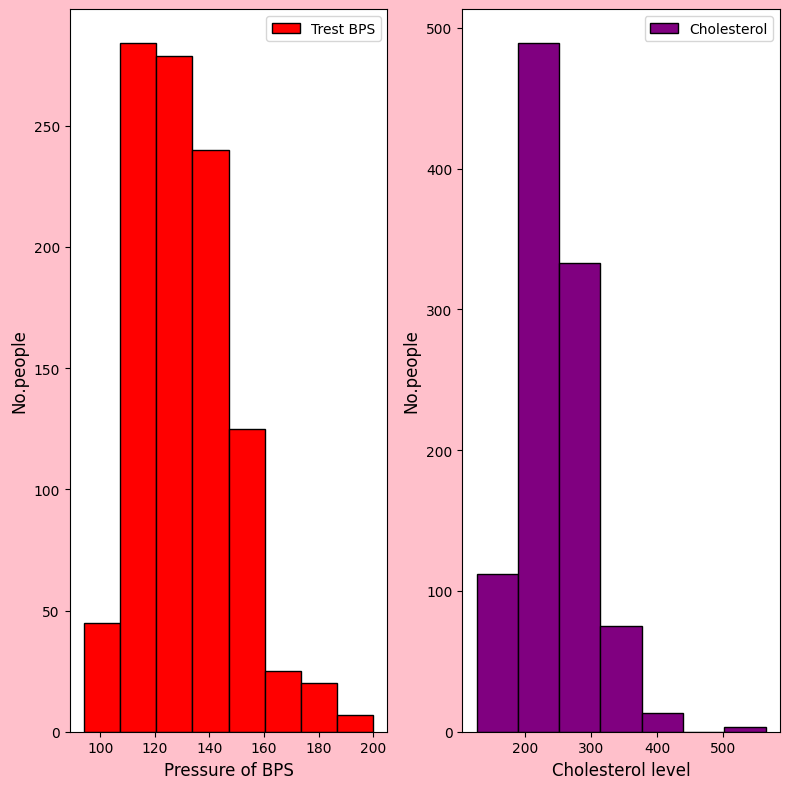

In [24]:
#COMPARE THE BPAS AND CHOL
plt.figure(facecolor='pink',figsize=(8,8))
plt.subplot(1,2,1)
plt.hist(df['trestbps'],bins=8,edgecolor='black',facecolor='red',label="Trest BPS")
plt.xlabel("Pressure of BPS",fontsize=12)
plt.ylabel("No.people",fontsize=12)
plt.legend()
plt.tight_layout()
plt.subplot(1,2,2)
plt.hist(df['chol'],bins=7,edgecolor='black',facecolor='purple',label='Cholesterol')
plt.xlabel("Cholesterol level",fontsize=12)
plt.ylabel("No.people",fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

* In this two hist chat we visualize the BPS and Cholesterol level of the patients
*   we draw this graph because we understand how many patients have same number of cholesterol level and BPS
*   And in both chart we clearly seen the distrebuation of the patients


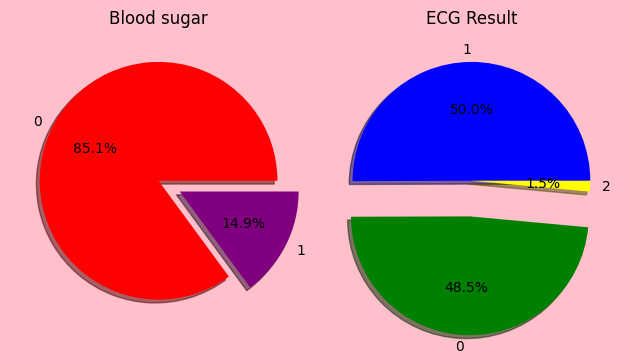

In [46]:
#BLOOD SUGAR AND ECG 
plt.figure(facecolor='pink')
plt.subplot(1,2,1)
explode=(0,0.2)
ad=df['fbs'].value_counts()
plt.pie(ad.values,labels=ad.index,autopct="%1.1f%%",colors=["red","purple"],explode=explode,shadow=True)
plt.title("Blood sugar")
plt.subplot(1,2,2)
explode=(0,0.3,0)
da=df['restecg'].value_counts()
plt.pie(da.values,labels=da.index,autopct="%1.1f%%",colors=["blue","green","yellow"],explode=explode,shadow=True)
plt.title("ECG Result")
plt.tight_layout()
plt.show()

1. In Blood Sugar 0 is show that the sugar level is less than 120mg and 1 show that the sugar level is greater than 120mg
2. In ECG the 0 is show that the ECG result is normal ,1 show that the ECG  have abnormal signal and 3 show that the Heart muscle is thick 

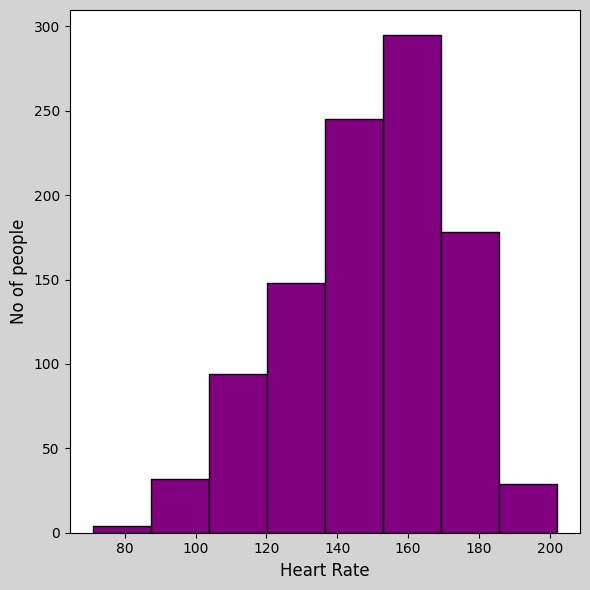

In [51]:
plt.figure(facecolor='LightGray',figsize=(6,6))
plt.hist(df['thalach'],bins=8,edgecolor="black",facecolor='purple')
plt.xlabel("Heart Rate",fontsize=12)
plt.ylabel("No of people",fontsize=12)
plt.tight_layout()
plt.show()

* in this graph we show that the maxium number of heart rate
* the graph show that the heart rate from 155 to 170 is the most patients in the data set

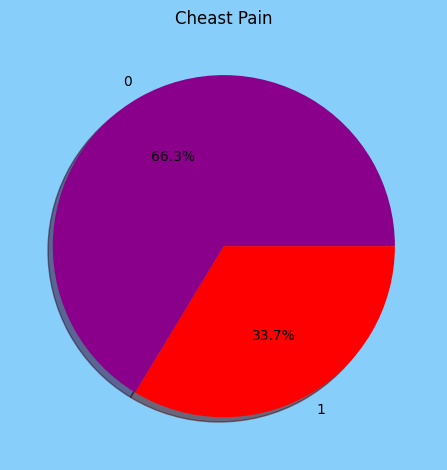

In [57]:
#CHEAST PAIN CHECK 
cp=df['exang'].value_counts()
plt.figure(facecolor='LightSkyBlue')
plt.pie(cp.values ,labels=cp.index,colors=["DarkMagenta","Red"],autopct="%1.1f%%",shadow=True)
plt.title("Cheast Pain")
plt.tight_layout()
plt.show()

1. 0 show that the patient have not cheast pain,the graph show that 66% patient have not cheast pain
2. 1 show that the patient have cheast pain ,in graph we see that 33.7% patient have cheast pain

# outlier
* to indetify outlier we use box plot 

In [67]:
# plt.boxplot(df['age'])
# plt.title("Age")
# plt.show()
# plt.boxplot(df['trestbps'])
# plt.show()
# plt.boxplot(df['chol'])
# plt.show()
# plt.boxplot(df['thalach'])
# plt.show()
# plt.boxplot(df['thal'])
# plt.show()




* found outlier at some columns but this value is actually real not a outlier so we don`t need to scale the data

# Model training and testing process

In [6]:
#SPLIT DATA 
dr_tr=df.drop(columns=['target']) # drop the target columns
st_tr=df['target']# stroe the target columns
#print(dr_tr)

# SPLIT INTO TRAIN AND TEST THE DATA
x_train,x_test,y_train,y_test=train_test_split(dr_tr,st_tr,test_size=0.3,random_state=42)

In [7]:
#TRAIN THE MODEL
model=DecisionTreeClassifier()
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)
probl=model.predict_proba(x_test)[:,1]



[1 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0
 1 1 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0 0 1
 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0 1 0 1 0
 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1
 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 0 1
 0 1 0 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0 0 1 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0
 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 1 0
 1 0 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 0 1 1 0 1 0 0 1
 1 0 0 1 0 0 1 1 0 0 0 0]


**MODEL EVALUATE**

In [8]:
ac=accuracy_score(prediction,y_test)  #check the model accuracy
cl=classification_report(prediction,y_test) # check the classification report
cn=confusion_matrix(prediction,y_test) # confusion matrix
cr_l=cross_val_score(model,dr_tr,st_tr,cv=5).mean() #check final accuracy of model by using this function
print(ac)
print(cl)
print(cn)
print(cr_l)

0.9707792207792207
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       168
           1       0.94      1.00      0.97       140

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308

[[159   9]
 [  0 140]]
1.0


# ROC_AUC

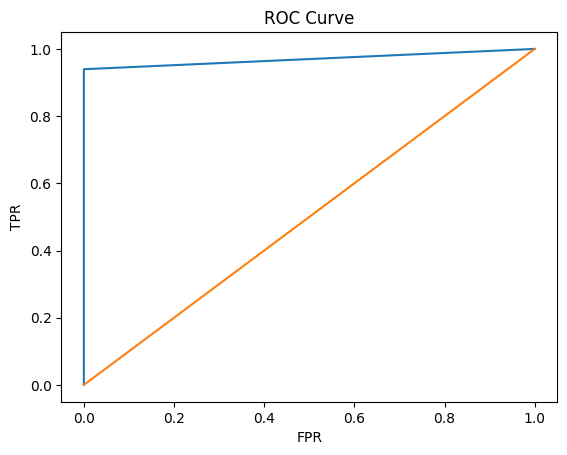

AUC: 0.9697986577181208


In [9]:
#ROC AND ROC-AUC

fpr,tpr,thared= roc_curve(y_test,probl) #roc to understand by the graph
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()
#ROC_AUC
auc = roc_auc_score(y_test, probl) # give precent ka hamra model atna precent thak kam kar raha ha 
print("AUC:", auc)


# Feature importance analysis 

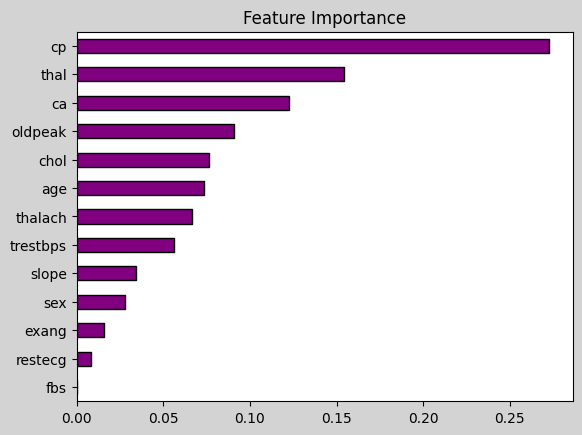

In [15]:
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=x_train.columns)
plt.figure(facecolor='LightGray')
feature_importance.sort_values().plot(kind='barh',edgecolor="black",facecolor='purple')
plt.title("Feature Importance")
plt.show()